## Défi quotidien : Classification de chiffres manuscrits à l'aide de réseaux de neurones convolutifs (CNN)

Ce notebook vous guidera à travers la construction et l'entraînement de deux modèles de classification de chiffres manuscrits sur l'ensemble de données MNIST : un réseau neuronal entièrement connecté et un réseau neuronal convolutif (CNN).

### 1. Charger l'ensemble de données MNIST

Nous allons commencer par charger l'ensemble de données MNIST en utilisant `keras.datasets.mnist.load_data()` et afficher les formes des données pour comprendre leur structure.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forme de x_train : (60000, 28, 28)
Forme de y_train : (60000,)
Forme de x_test : (10000, 28, 28)
Forme de y_test : (10000,)


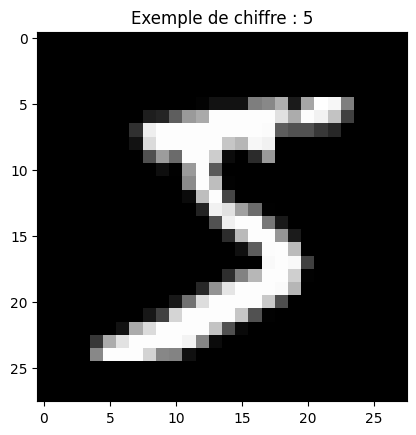

In [1]:
import keras
from keras.datasets import mnist
import numpy as np

# Charger l'ensemble de données MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Afficher les formes des données chargées
print(f"Forme de x_train : {x_train.shape}") # (60000, 28, 28)
print(f"Forme de y_train : {y_train.shape}") # (60000,)
print(f"Forme de x_test : {x_test.shape}")   # (10000, 28, 28)
print(f"Forme de y_test : {y_test.shape}")     # (10000,)

# Afficher un exemple d'image
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Exemple de chiffre : {y_train[0]}")
plt.show()

### 2. Prétraitement des données pour un réseau neuronal entièrement connecté

Pour un réseau neuronal entièrement connecté, nous devons:
- Aplatir les images de 28x28 pixels en un vecteur de 784 pixels.
- Normaliser les valeurs des pixels (les diviser par 255) pour qu'elles soient entre 0 et 1.
- Encoder les étiquettes cibles en format one-hot (par exemple, le chiffre '5' devient `[0,0,0,0,0,1,0,0,0,0]`).

In [2]:
# Aplatir les images
x_train_flat = x_train.reshape(x_train.shape[0], 28 * 28)
x_test_flat = x_test.reshape(x_test.shape[0], 28 * 28)

# Normaliser les valeurs des pixels
x_train_flat = x_train_flat.astype('float32') / 255
x_test_flat = x_test_flat.astype('float32') / 255

# Encoder les étiquettes en one-hot
num_classes = 10
y_train_one_hot = keras.utils.to_categorical(y_train, num_classes)
y_test_one_hot = keras.utils.to_categorical(y_test, num_classes)

print(f"Forme de x_train_flat après aplatissement et normalisation : {x_train_flat.shape}")
print(f"Forme de y_train_one_hot après encodage one-hot : {y_train_one_hot.shape}")

Forme de x_train_flat après aplatissement et normalisation : (60000, 784)
Forme de y_train_one_hot après encodage one-hot : (60000, 10)


### 3. Construire et entraîner un réseau neuronal entièrement connecté

Nous allons créer un modèle `Sequential` avec des couches `Dense` et des fonctions d'activation `relu` et `softmax` pour la couche de sortie. Le modèle sera compilé avec l'optimiseur Adam et la fonction de perte 'categorical_crossentropy'.

In [3]:
from keras.models import Sequential
from keras.layers import Dense

# Construire le modèle entièrement connecté
model_dense = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compiler le modèle
model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Afficher un résumé du modèle
model_dense.summary()

# Entraîner le modèle
history_dense = model_dense.fit(x_train_flat, y_train_one_hot, epochs=10, batch_size=128, validation_split=0.2)

# Évaluer le modèle
loss_dense, accuracy_dense = model_dense.evaluate(x_test_flat, y_test_one_hot, verbose=0)
print(f"Précision du modèle entièrement connecté sur l'ensemble de test : {accuracy_dense:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9271 - loss: 0.2493 - val_accuracy: 0.9599 - val_loss: 0.1317
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9721 - loss: 0.0916 - val_accuracy: 0.9667 - val_loss: 0.1080
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9822 - loss: 0.0562 - val_accuracy: 0.9730 - val_loss: 0.0932
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9879 - loss: 0.0381 - val_accuracy: 0.9728 - val_loss: 0.0924
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9915 - loss: 0.0271 - val_accuracy: 0.9782 - val_loss: 0.0827
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9927 - loss: 0.0226 - val_accuracy: 0.9764 - val_loss: 0.0876
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9942 - loss: 0.0183 - val_accuracy: 0.9729 - val_loss: 0.1069
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9941 - loss: 0.0173 - val_ac

### 4. Prétraitement des données pour un réseau neuronal convolutif (CNN)

Pour un CNN, nous devons:
- Remodeler les données d'entrée à la forme attendue par une couche `Conv2D` : `(nombre_d'images, hauteur, largeur, nombre_de_canaux)`. Pour les images MNIST en niveaux de gris, ce sera `(60000, 28, 28, 1)`.
- Normaliser les valeurs des pixels en les divisant par 255.
- Encoder les étiquettes cibles en format one-hot (nous pouvons réutiliser `y_train_one_hot` et `y_test_one_hot` si elles n'ont pas été modifiées).

In [4]:
# Remodeler les données pour Conv2D (ajoute un canal de couleur)
x_train_cnn = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test_cnn = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Normaliser les valeurs des pixels
x_train_cnn = x_train_cnn.astype('float32') / 255
x_test_cnn = x_test_cnn.astype('float32') / 255

# Les étiquettes one-hot sont déjà prêtes : y_train_one_hot, y_test_one_hot

print(f"Forme de x_train_cnn après remodelage et normalisation : {x_train_cnn.shape}")

Forme de x_train_cnn après remodelage et normalisation : (60000, 28, 28, 1)


### 5. Concevoir et entraîner un réseau neuronal convolutif (CNN)

Nous allons construire un CNN avec des couches `Conv2D`, `MaxPool2D`, `Flatten` et `Dense`. Le modèle sera compilé et entraîné de manière similaire au réseau neuronal entièrement connecté.

In [5]:
from keras.layers import Conv2D, MaxPooling2D, Flatten

# Construire le modèle CNN
model_cnn = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compiler le modèle
model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Afficher un résumé du modèle
model_cnn.summary()

# Entraîner le modèle
history_cnn = model_cnn.fit(x_train_cnn, y_train_one_hot, epochs=10, batch_size=128, validation_split=0.2)

# Évaluer le modèle
loss_cnn, accuracy_cnn = model_cnn.evaluate(x_test_cnn, y_test_one_hot, verbose=0)
print(f"Précision du modèle CNN sur l'ensemble de test : {accuracy_cnn:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 49s 128ms/step - accuracy: 0.9290 - loss: 0.2375 - val_accuracy: 0.9801 - val_loss: 0.0712
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 107ms/step - accuracy: 0.9815 - loss: 0.0605 - val_accuracy: 0.9856 - val_loss: 0.0527
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.9865 - loss: 0.0440 - val_accuracy: 0.9877 - val_loss: 0.0437
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 104ms/step - accuracy: 0.9900 - loss: 0.0328 - val_accuracy: 0.9877 - val_loss: 0.0425
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.9917 - loss: 0.0257 - val_accuracy: 0.9899 - val_loss: 0.0344
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.9933 - loss: 0.0206 - val_accuracy: 0.9877 - val_loss: 0.0397
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.9946 - loss: 0.0164 - val_accuracy: 0.9861 - val_loss: 0.0475
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 104ms/step - accuracy: 0.9956 - loss: 0

### 6. Comparer les performances

Nous allons analyser la précision des deux modèles et observer la différence entre le modèle entièrement connecté et le modèle CNN.

--- Comparaison des performances des modèles ---
Précision du réseau neuronal entièrement connecté : 0.9789
Précision du réseau neuronal convolutif (CNN) : 0.9916
Le CNN a obtenu une meilleure précision que le réseau neuronal entièrement connecté.


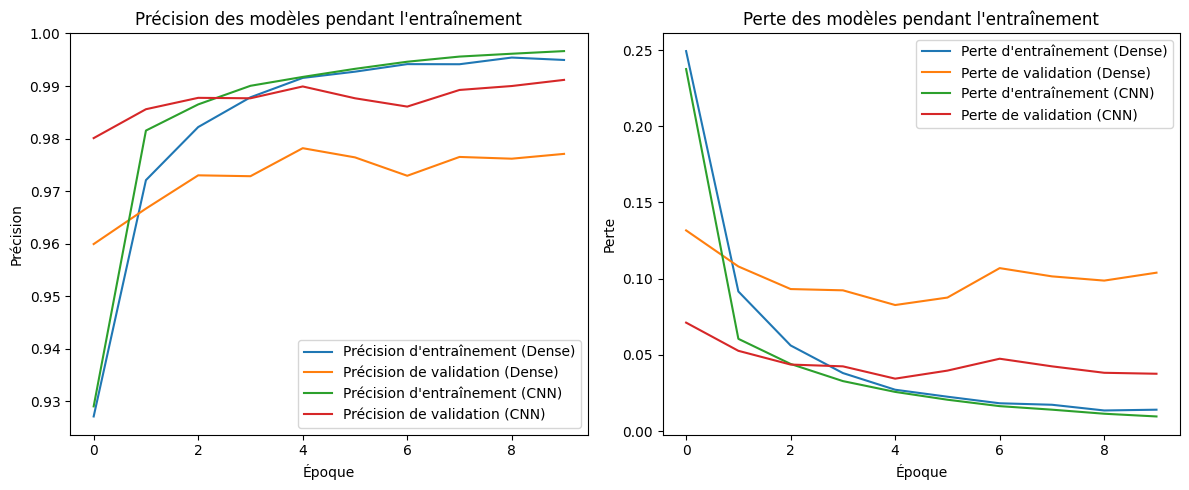

In [6]:
print(f"--- Comparaison des performances des modèles ---")
print(f"Précision du réseau neuronal entièrement connecté : {accuracy_dense:.4f}")
print(f"Précision du réseau neuronal convolutif (CNN) : {accuracy_cnn:.4f}")

if accuracy_cnn > accuracy_dense:
    print("Le CNN a obtenu une meilleure précision que le réseau neuronal entièrement connecté.")
elif accuracy_cnn < accuracy_dense:
    print("Le réseau neuronal entièrement connecté a obtenu une meilleure précision que le CNN (ce qui est inhabituel pour la classification d'images).")
else:
    print("Les deux modèles ont obtenu une précision similaire.")

# Visualisation de l'historique d'entraînement
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dense.history['accuracy'], label='Précision d\'entraînement (Dense)')
plt.plot(history_dense.history['val_accuracy'], label='Précision de validation (Dense)')
plt.plot(history_cnn.history['accuracy'], label='Précision d\'entraînement (CNN)')
plt.plot(history_cnn.history['val_accuracy'], label='Précision de validation (CNN)')
plt.title('Précision des modèles pendant l\'entraînement')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dense.history['loss'], label='Perte d\'entraînement (Dense)')
plt.plot(history_dense.history['val_loss'], label='Perte de validation (Dense)')
plt.plot(history_cnn.history['loss'], label='Perte d\'entraînement (CNN)')
plt.plot(history_cnn.history['val_loss'], label='Perte de validation (CNN)')
plt.title('Perte des modèles pendant l\'entraînement')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()

plt.tight_layout()
plt.show()